## Install libs

In [ ]:
!pip install ragas datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.0 MB/s eta 0:00:00


## Download data

In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch

In [ ]:
import json

def read_json(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
      queries = json.load(f)

    return queries

In [ ]:
questions = read_json('rag_questions.json')
chunks = read_json('semantic_chunks_by_threshold (1).json')

In [ ]:
chunks['0.3'][10]

'DeepSeek is passing along the cost savings to developers, offering high-performance inference at a fraction of the cost of closed models.We’re thinking:\xa0DeepSeek-R1-0528-Qwen3-8B mixes contributions from open-weight models — possible only because Qwen3’s license, like DeepSeek’s is permissive. Open models enable experimentation and innovation in ways that closed models do not.'

In [ ]:
questions[0]

{'question': 'What course did AI Fund provide to non-engineers to help them get started with AI coding?',
 'ground_truth': 'A course called “AI Python for Beginners” was given to all non-engineers at AI Fund.'}

In [ ]:
documents = chunks['0.3']

## Evaluate 3 moder for retrival

In [ ]:
base_model = SentenceTransformer('all-MiniLM-L6-v2')
model_1 = SentenceTransformer('all-mpnet-base-v2')
model_2 = SentenceTransformer('multi-qa-mpnet-base-dot-v1')

In [ ]:
corpus = documents
corpus_embeddings = base_model.encode(corpus, convert_to_tensor=True)

In [ ]:
corpus_embeddings_base_model = corpus_embeddings

In [ ]:
corpus_embeddings_mpnet_base_v2 = corpus_embeddings

In [ ]:
corpus_embeddings_mpnet_base_dot_v1 = corpus_embeddings

In [ ]:
embeddings_by_model = {
    "mpnet_base_dot_v1": corpus_embeddings_mpnet_base_dot_v1,
    "mpnet_base_v2": corpus_embeddings_mpnet_base_v2,
    "base_model": corpus_embeddings_base_model
}

In [ ]:
test_questions = []
groud_truth = []

for question in questions:
    test_questions.append(question['question'])
    groud_truth.append(question['ground_truth'])

In [ ]:
embeddings_base_questions = base_model.encode(test_questions, convert_to_tensor=True)
embeddings_model_1_questions = model_1.encode(test_questions, convert_to_tensor=True)
embeddings_model_2_questions = model_2.encode(test_questions, convert_to_tensor=True)

In [ ]:
question_embeddings_by_model = {
    "base_model": embeddings_base_questions,       # cosine
    "mpnet_base_v2": embeddings_model_1_questions, # cosine
    "mpnet_base_dot_v1": embeddings_model_2_questions  # dot product
}

corpus_embeddings_by_model = {
    "base_model": corpus_embeddings_base_model,
    "mpnet_base_v2": corpus_embeddings_mpnet_base_v2,
    "mpnet_base_dot_v1": corpus_embeddings_mpnet_base_dot_v1
}

In [ ]:
similarity_type = {
    "base_model": "cosine",
    "mpnet_base_v2": "cosine",
    "mpnet_base_dot_v1": "dot"
}

In [ ]:
top_docs_by_model = {}

for model_name in question_embeddings_by_model:
    print(f"\n🔍 Evaluating: {model_name}")

    q_embs = question_embeddings_by_model[model_name]
    doc_embs = corpus_embeddings_by_model[model_name]

    sim_type = similarity_type[model_name]

    model_results = []

    for i, query_emb in enumerate(q_embs):
        if sim_type == "cosine":
            scores = util.cos_sim(query_emb, doc_embs)[0]
        else:  # dot product
            scores = torch.matmul(doc_embs, query_emb)

        top_k = torch.topk(scores, k=5)
        top_idxs = top_k.indices.tolist()
        top_scores = top_k.values.tolist()

        top_results = [(documents[idx], top_scores[j]) for j, idx in enumerate(top_idxs)]
        model_results.append({
            "question": test_questions[i],
            "top_documents": top_results
        })

    top_docs_by_model[model_name] = model_results

In [ ]:
from datasets import Dataset

def prepare_ragas_dataset(model_results, reference_answers):
    questions = []
    contexts = []
    ground_truths = []
    answers = []

    for entry, ref in zip(model_results, reference_answers):
        questions.append(entry["question"])
        ground_truths.append(ref)
        answers.append(ref)

        # Extract just the text (no scores)
        retrieved_contexts = [doc for doc, score in entry["top_documents"]]
        contexts.append(retrieved_contexts)

    return Dataset.from_dict({
        "question": questions,
        "contexts": contexts,
        "answer": answers,
        "ground_truth": ground_truths
    })

In [ ]:
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
)
from ragas import evaluate

metrics = [
    context_precision,
    context_recall
]

In [ ]:
from dotenv import load_dotenv

load_dotenv()

True

## Result evaluating

In [ ]:
ragas_results = {}

for model_name, model_results in top_docs_by_model.items():
    print(f"\n📊 Evaluating RAGAS for: {model_name}")

    dataset = prepare_ragas_dataset(model_results, groud_truth)
    result = evaluate(dataset, metrics=metrics)

    ragas_results[model_name] = result
    print(result)


📊 Evaluating RAGAS for: base_model


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

{'context_precision': 0.7563, 'context_recall': 0.7667}

📊 Evaluating RAGAS for: mpnet_base_v2


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

{'context_precision': 0.5771, 'context_recall': 0.7167}

📊 Evaluating RAGAS for: mpnet_base_dot_v1


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

{'context_precision': 0.7011, 'context_recall': 0.8333}


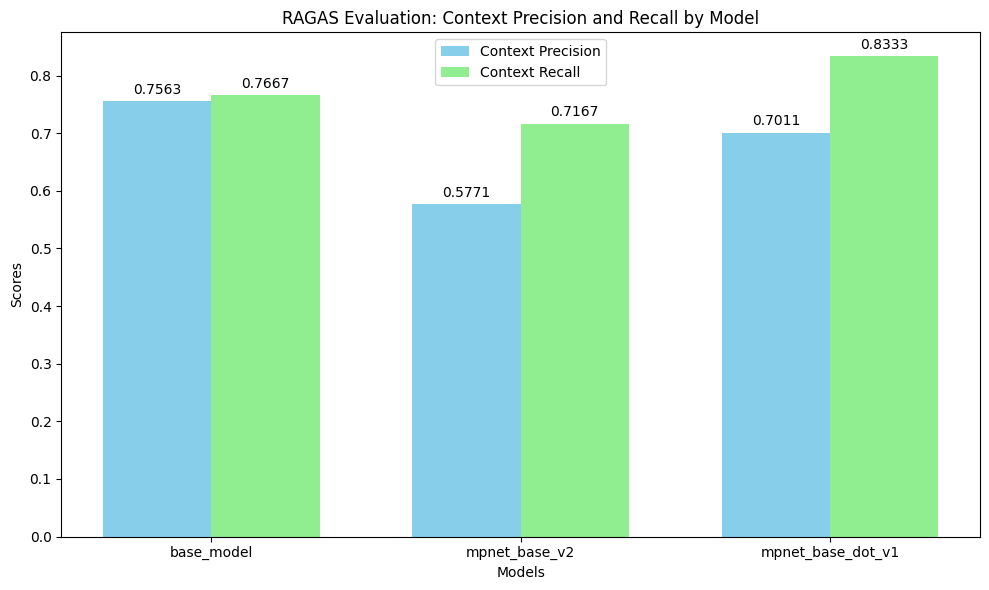

In [1]:
import matplotlib.pyplot as plt
import numpy as np

models = ['base_model', 'mpnet_base_v2', 'mpnet_base_dot_v1']
context_precision = [0.7563, 0.5771, 0.7011]
context_recall = [0.7667, 0.7167, 0.8333]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, context_precision, width, label='Context Precision', color='skyblue')
bars2 = ax.bar(x + width/2, context_recall, width, label='Context Recall', color='lightgreen')

ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('RAGAS Evaluation: Context Precision and Recall by Model')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()

plt.show()